In [1]:
import pandas as pd
import numpy as np
from  sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip install mldatasets


ERROR: Could not find a version that satisfies the requirement mldatasets (from versions: none)
ERROR: No matching distribution found for mldatasets
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install openml

Note: you may need to restart the kernel to use updated packages.


In [4]:


url = "https://raw.githubusercontent.com/SaneSky109/DATA606/main/Data_Project/Data/cardio_train.csv"

cvd_df = pd.read_csv(url, sep=";")

cvd_df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
df=cvd_df


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
#begin feature enginnering part
df['age']=df['age']/365


In [8]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.000000,25006.750000,50001.500000,74889.250000,99999.000000
age,70000.0,53.339358,6.759594,29.583562,48.394521,53.980822,58.430137,64.967123
gender,70000.0,1.349571,0.476838,1.000000,1.000000,1.000000,2.000000,2.000000
height,70000.0,164.359229,8.210126,55.000000,159.000000,165.000000,170.000000,250.000000
weight,70000.0,74.205690,14.395757,10.000000,65.000000,72.000000,82.000000,200.000000
ap_hi,70000.0,128.817286,154.011419,-150.000000,120.000000,120.000000,140.000000,16020.000000
ap_lo,70000.0,96.630414,188.472530,-70.000000,80.000000,80.000000,90.000000,11000.000000
cholesterol,70000.0,1.366871,0.680250,1.000000,1.000000,1.000000,2.000000,3.000000
gluc,70000.0,1.226457,0.572270,1.000000,1.000000,1.000000,1.000000,3.000000
smoke,70000.0,0.088129,0.283484,0.000000,0.000000,0.000000,0.000000,1.000000


In [9]:
df=df.loc[df.ap_hi>=df.ap_lo,:].reset_index(drop=True)

In [10]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0


In [11]:
y=df['cardio']
x=df.iloc[:,:-1]

In [12]:
x

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
0,0,50.391781,2,168,62.0,110,80,1,1,0,0,1
1,1,55.419178,1,156,85.0,140,90,3,1,0,0,1
2,2,51.663014,1,165,64.0,130,70,3,1,0,0,0
3,3,48.282192,2,169,82.0,150,100,1,1,0,0,1
4,4,47.873973,1,156,56.0,100,60,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
68761,99993,52.712329,2,168,76.0,120,80,1,1,1,0,1
68762,99995,61.920548,1,158,126.0,140,90,2,2,0,0,1
68763,99996,52.235616,2,183,105.0,180,90,3,1,0,1,0
68764,99998,61.454795,1,163,72.0,135,80,1,2,0,0,0


In [13]:
X_train,X_test, y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=18)

In [14]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [15]:
model.fit(X_train,y_train)

/workspaces/Interpretable-machine-learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [16]:
print(model.coef_)

[[-7.21836578e-07  3.89615454e-02  8.77558757e-04 -5.37235501e-02
   1.97245871e-02  2.51791394e-02  2.62673848e-02  7.01989450e-03
   1.43079450e-03 -1.68852374e-04 -2.15495938e-04 -1.74390003e-03]]


In [17]:
model.coef_

array([[-7.21836578e-07,  3.89615454e-02,  8.77558757e-04,
        -5.37235501e-02,  1.97245871e-02,  2.51791394e-02,
         2.62673848e-02,  7.01989450e-03,  1.43079450e-03,
        -1.68852374e-04, -2.15495938e-04, -1.74390003e-03]])

In [18]:
#将model coefficient 和 features 匹配

coef_df=pd.DataFrame({'feature':x.columns,'coefficent':model.coef_[0]})

print(coef_df)

        feature    coefficent
0            id -7.218366e-07
1           age  3.896155e-02
2        gender  8.775588e-04
3        height -5.372355e-02
4        weight  1.972459e-02
5         ap_hi  2.517914e-02
6         ap_lo  2.626738e-02
7   cholesterol  7.019894e-03
8          gluc  1.430795e-03
9         smoke -1.688524e-04
10         alco -2.154959e-04
11       active -1.743900e-03


In [19]:
model.coef_[0]

array([-7.21836578e-07,  3.89615454e-02,  8.77558757e-04, -5.37235501e-02,
        1.97245871e-02,  2.51791394e-02,  2.62673848e-02,  7.01989450e-03,
        1.43079450e-03, -1.68852374e-04, -2.15495938e-04, -1.74390003e-03])

In [20]:

#预测test 里面的数据的prob
proba=model.predict_proba(X_test)

In [21]:
#检查数据的类型格式
type(proba)

numpy.ndarray

In [22]:
#looking a proba for one specific observation 

print(X_test.iloc[2872])

id             53819.000000
age               39.547945
gender             2.000000
height           185.000000
weight            99.000000
ap_hi            120.000000
ap_lo             80.000000
cholesterol        2.000000
gluc               1.000000
smoke              0.000000
alco               0.000000
active             1.000000
Name: 37013, dtype: float64


In [23]:
%pip install shap


Note: you may need to restart the kernel to use updated packages.


In [24]:
import shap

/workspaces/Interpretable-machine-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
explanier=shap.Explainer(model,X_train)

Background dataset has 58451 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=58451 when initializing the masker.


In [26]:
shap_values=explanier(X_test)

In [27]:
shap_values.shape

(10315, 12)

In [28]:
shap_values[0].values

array([ 3.23765794e-02,  1.90029867e-01,  5.26535254e-04, -2.60021982e-01,
       -2.77524941e-01, -1.81793386e-01, -2.33779725e-02, -2.03576940e-03,
       -4.57854241e-04, -1.57032708e-04,  1.07747969e-05,  1.34280302e-03])

In [29]:
shap_df=pd.DataFrame({ "feature": X_test.columns,
    "feature_value": X_test.iloc[0].values,
    "shap_value": shap_values[0].values
})

In [30]:
shap_df

,feature,feature_value,shap_value
0,id,7203.00000,0.032377
1,age,58.49863,0.190030
2,gender,2.00000,0.000527
3,height,169.00000,-0.260022
4,weight,60.00000,-0.277525
5,ap_hi,120.00000,-0.181793
6,ap_lo,80.00000,-0.023378
7,cholesterol,1.00000,-0.002036
8,gluc,1.00000,-0.000458
9,smoke,1.00000,-0.000157


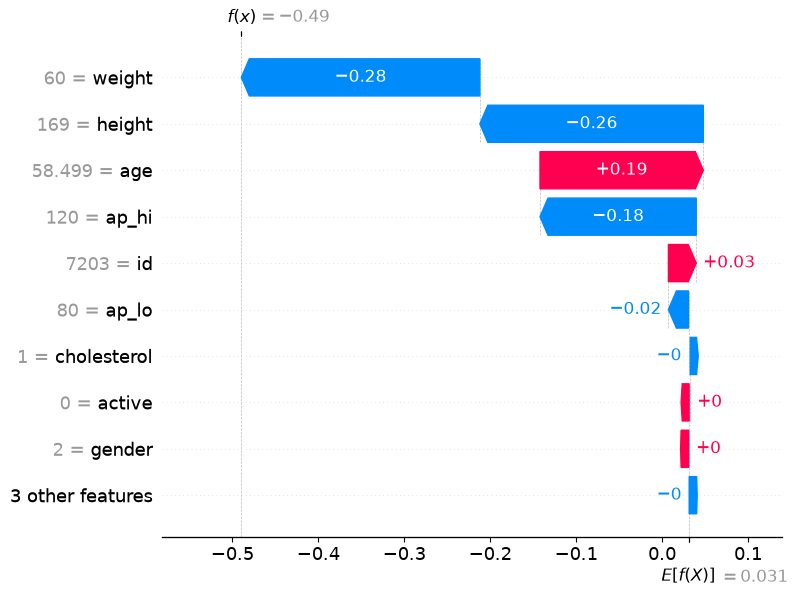

In [31]:
shap.plots.waterfall(shap_values[0])

In [32]:
shap.plots.bar(shap_df)

TypeError: The shap_values argument must be an Explanation object, Cohorts object, or dictionary of Explanation objects!

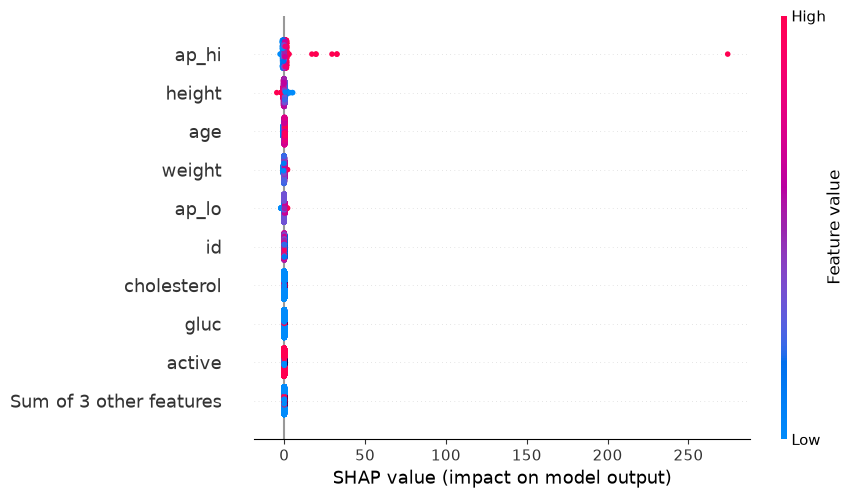

In [33]:
shap.plots.beeswarm(shap_values)